In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
import torchmetrics
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights, resnet152, ResNet152_Weights, efficientnet_b0, EfficientNet_B0_Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
class LatentMultiHeadAttention(nn.Module):
    """Latent Multi-Head Attention using fixed latent spatial resolution."""
    def __init__(self, dim=320, num_heads=5, latent_dim=49):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** 0.5
        
        # latent_tokens now has shape (1, latent_dim, dim) with latent_dim=49 (7x7 grid)
        self.latent_tokens = nn.Parameter(torch.randn(1, latent_dim, dim))

        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, C, H, W = x.shape  # Expected input: (B, 320, H, W)
        # Flatten spatial dimensions: (B, HW, C)
        x = x.view(B, C, -1).permute(0, 2, 1)  # (B, HW, C)
        
        # Expand latent tokens: (B, latent_dim, C)
        latent_expanded = self.latent_tokens.expand(B, -1, -1)  # (B, latent_dim, C)
        
        # Linear projections
        q = self.query(latent_expanded)  # (B, latent_dim, C)
        k = self.key(x)                  # (B, HW, C)
        v = self.value(x)                # (B, HW, C)
        
        # Reshape to multi-head attention
        # Split heads: (B, num_heads, seq_len, head_dim)
        q = q.view(B, -1, self.num_heads, self.head_dim).permute(0, 2, 1, 3)  # (B, num_heads, latent_dim, head_dim)
        k = k.view(B, -1, self.num_heads, self.head_dim).permute(0, 2, 1, 3)  # (B, num_heads, HW, head_dim)
        v = v.view(B, -1, self.num_heads, self.head_dim).permute(0, 2, 1, 3)  # (B, num_heads, HW, head_dim)
        
        # Compute attention for each head
        attn = torch.matmul(q, k.transpose(-2, -1)) / self.scale  # (B, num_heads, latent_dim, HW)
        attn = F.softmax(attn, dim=-1)
        
        # Apply attention to values
        out = torch.matmul(attn, v)  # (B, num_heads, latent_dim, head_dim)
        
        # Merge heads: (B, latent_dim, C)
        out = out.permute(0, 2, 1, 3).contiguous().view(B, -1, C)
        
        # Final projection
        out = self.proj(out)  # (B, latent_dim, C)
        
        # Reshape to spatial layout: (B, C, new_h, new_w)
        out = out.permute(0, 2, 1)  # (B, C, latent_dim)
        new_spatial = int(self.latent_tokens.shape[1] ** 0.5)  # should be 7
        out = out.view(B, C, new_spatial, new_spatial)  # (B, C, 7, 7)
        
        return out

class MultiScaleMobileNetDehaze(nn.Module):
    def __init__(self):
        super().__init__()
        self.downsample = T.Resize((256, 256))  # Keep original input size

        # Get MobileNetV3-Small model
        mobilenet = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        
        # Extract features at different scales (keep original)
        # Scale 1: 1/4 resolution (64x64) - 16 channels
        self.encoder_s1 = nn.Sequential(*list(mobilenet.features[:2]))
        
        # Scale 2: 1/8 resolution (32x32) - 24 channels
        self.encoder_s2 = nn.Sequential(*list(mobilenet.features[2:4]))
        
        # Scale 3: 1/16 resolution (16x16) - 40 channels
        self.encoder_s3 = nn.Sequential(*list(mobilenet.features[4:7]))
        
        # Channel mappers for each scale - slightly reduced
        self.intermediate_dim = 320  # Down from 384
        self.mapper_s1 = nn.Conv2d(16, self.intermediate_dim // 4, kernel_size=1)
        self.mapper_s2 = nn.Conv2d(24, self.intermediate_dim // 4, kernel_size=1)
        self.mapper_s3 = nn.Conv2d(40, self.intermediate_dim // 2, kernel_size=1)
        
        # Multi-head attention module
        self.mhla = LatentMultiHeadAttention(dim=self.intermediate_dim, num_heads=5, latent_dim=49)
        
        # Feature fusion layer
        self.fusion = nn.Conv2d(self.intermediate_dim, self.intermediate_dim, kernel_size=3, padding=1)
        
        # Decoder: Slightly reduced dimensions
        self.decoder_1 = nn.Sequential(
            nn.Conv2d(self.intermediate_dim, 160, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.decoder_2 = nn.Sequential(
            nn.Conv2d(160, 80, kernel_size=3, padding=1),
            nn.ReLU()
        )
        self.decoder_3 = nn.Conv2d(80, 3, kernel_size=3, padding=1)

        # Skip connection mapping layers
        # self.skip_mapper_1 = nn.Conv2d(3, 160, kernel_size=1)
        # self.skip_mapper_2 = nn.Conv2d(3, 80, kernel_size=1)
        self.skip_mapper_1 = nn.Conv2d(80, 160, kernel_size=1)  # For m1 features
        self.skip_mapper_2 = nn.Conv2d(80, 80, kernel_size=1)   # For m2 features

    def forward(self, x):
        original_size = (x.shape[2], x.shape[3])
        input_x = x.clone()  # Store input for skip connections
        x = self.downsample(x)          # (B, 3, 256, 256)
        input_resized = self.downsample(input_x)  # Resize input for skip connections
        
        # Multi-scale feature extraction
        f1 = self.encoder_s1(x)         # (B, 16, 64, 64)
        f2 = self.encoder_s2(f1)        # (B, 24, 32, 32)
        f3 = self.encoder_s3(f2)        # (B, 40, 16, 16)
        
        # Transform features to common dimension
        m1 = self.mapper_s1(f1)         # (B, 80, 64, 64)
        m2 = self.mapper_s2(f2)         # (B, 80, 32, 32)
        m3 = self.mapper_s3(f3)         # (B, 160, 16, 16)
        
        # Resize all features to the same resolution (16x16)
        m1 = F.interpolate(m1, size=(16, 16), mode='bilinear', align_corners=False)
        m2 = F.interpolate(m2, size=(16, 16), mode='bilinear', align_corners=False)
        
        # Concatenate multi-scale features
        multi_scale_features = torch.cat([m1, m2, m3], dim=1)  # (B, 320, 16, 16)
        
        # Apply fusion layer
        fused_features = self.fusion(multi_scale_features)
        
        # Apply attention
        attended_features = self.mhla(fused_features)  # (B, 320, 7, 7)
        
        # Upsample to original resolution
        x = F.interpolate(attended_features, size=(256, 256), mode='bilinear', align_corners=False)
        
        # Decode with skip connections
        x1 = self.decoder_1(x)             # (B, 160, 256, 256)
        skip1 = self.skip_mapper_1(F.interpolate(m1, size=(256, 256), mode='bilinear', align_corners=False))   # Map from 80->160 channels
        x1 = x1 + skip1  # First skip connection
        
        x2 = self.decoder_2(x1)            # (B, 80, 256, 256)
        skip2 = self.skip_mapper_2(F.interpolate(m2, size=(256, 256), mode='bilinear', align_corners=False))  # Map from 80->80 channels
        x2 = x2 + skip2  # Second skip connection
        
        x3 = self.decoder_3(x2)            # (B, 3, 256, 256)
        x3 = x3 + input_resized  # Direct skip connection to input (residual learning)
        
        x_out = torch.clamp(x3, 0.0, 1.0)
        
        # Resize back to original input size if needed
        if original_size != (256, 256):
            x_out = F.interpolate(x_out, size=original_size, mode='bilinear', align_corners=False)
            
        return x_out

# Model Initialization
model = MultiScaleMobileNetDehaze().to(device)
print(f"Model Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6:.2f}M")

# Testing with a dummy input
dummy_input = torch.randn(1, 3, 256, 256).to(device)
output = model(dummy_input)
print("Output shape:", output.shape)  # Expected: [1, 3, 256, 256]

input_shape = (1, 3, 256, 256)
summary(model, input_size=input_shape, col_names=["input_size", "output_size", "num_params"])

Model Parameters: 2.09M
Output shape: torch.Size([1, 3, 256, 256])


Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
MultiScaleMobileNetDehaze                          [1, 3, 256, 256]          [1, 3, 256, 256]          --
├─Resize: 1-1                                      [1, 3, 256, 256]          [1, 3, 256, 256]          --
├─Resize: 1-2                                      [1, 3, 256, 256]          [1, 3, 256, 256]          --
├─Sequential: 1-3                                  [1, 3, 256, 256]          [1, 16, 64, 64]           --
│    └─Conv2dNormActivation: 2-1                   [1, 3, 256, 256]          [1, 16, 128, 128]         --
│    │    └─Conv2d: 3-1                            [1, 3, 256, 256]          [1, 16, 128, 128]         432
│    │    └─BatchNorm2d: 3-2                       [1, 16, 128, 128]         [1, 16, 128, 128]         32
│    │    └─Hardswish: 3-3                         [1, 16, 128, 128]         [1, 16, 128, 128]         --
│    └─InvertedResidual: 2-2            

In [3]:
class DehazeDataset(Dataset):
    def __init__(self, haze_dir, clear_dir, transform=None):
        self.haze_dir = haze_dir
        self.clear_dir = clear_dir
        self.transform = transform
        self.image_ids = sorted(set(f.split('_')[0] for f in os.listdir(haze_dir)))
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        
        haze_files = sorted([f for f in os.listdir(self.haze_dir) if f.startswith(image_id)])
        clear_file = f"{image_id}.png"
        
        if not haze_files or not os.path.exists(os.path.join(self.clear_dir, clear_file)):
            return None
        
        haze_path = os.path.join(self.haze_dir, haze_files[0])  # Take first hazy image
        clear_path = os.path.join(self.clear_dir, clear_file)
        
        haze_img = cv2.imread(haze_path)
        clear_img = cv2.imread(clear_path)
        
        haze_img = cv2.cvtColor(haze_img, cv2.COLOR_BGR2RGB)
        clear_img = cv2.cvtColor(clear_img, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            haze_img = self.transform(haze_img)
            clear_img = self.transform(clear_img)
        
        return haze_img, clear_img

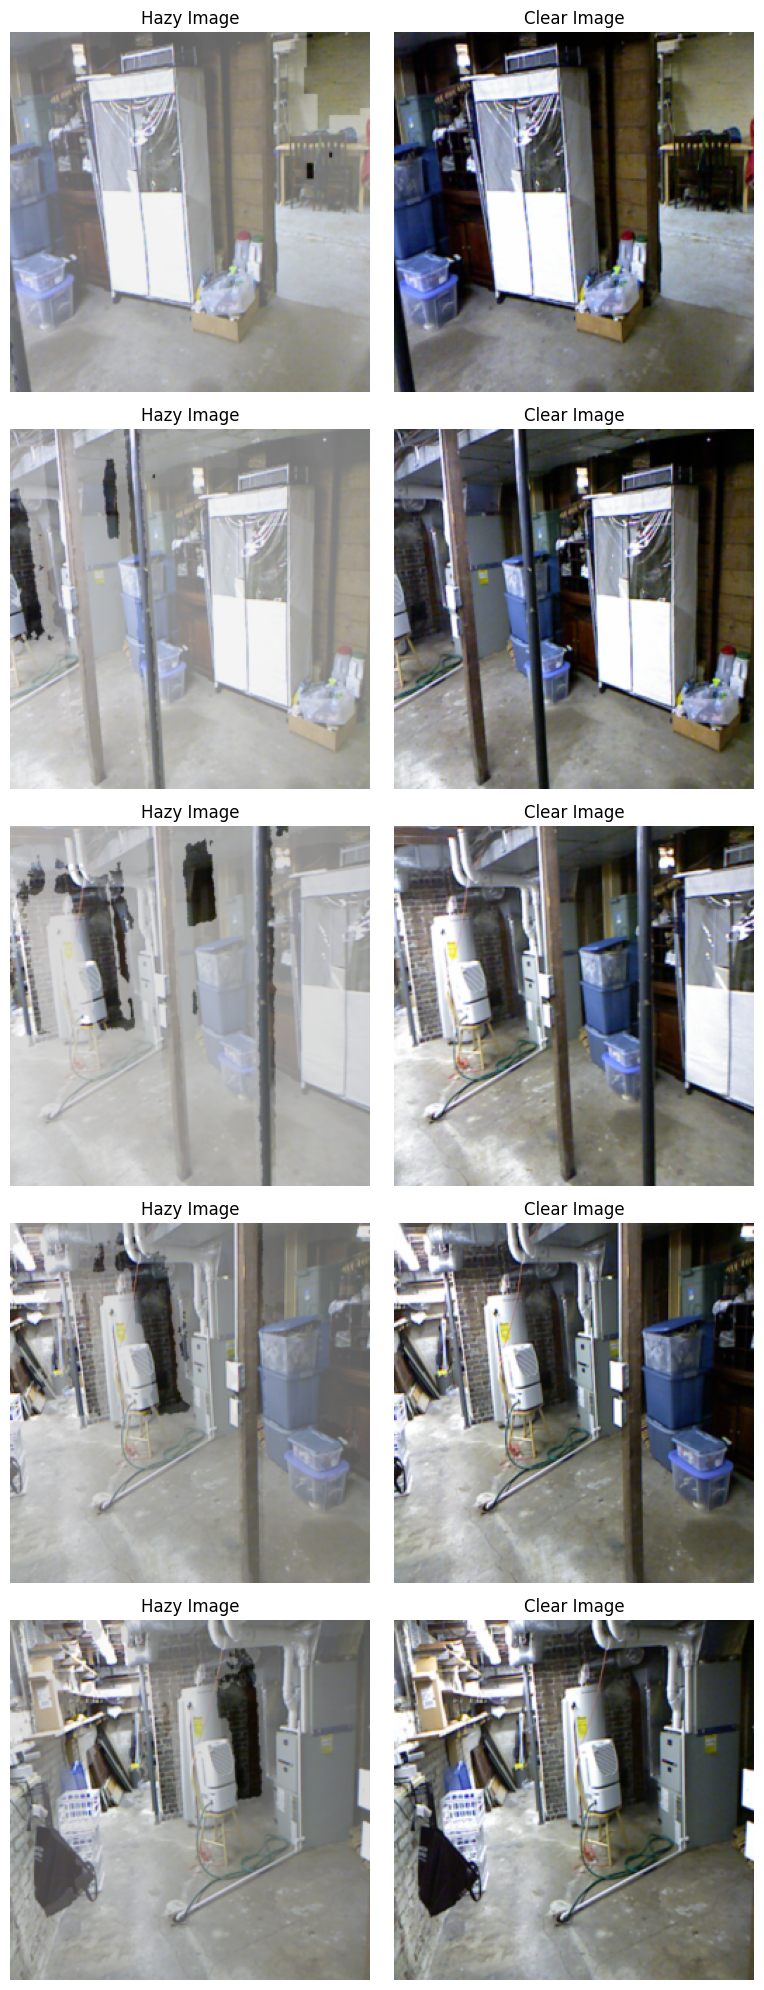

In [11]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 256)),
    T.ToTensor()
])

dataset = DehazeDataset('Dataset/ITS_haze', 'Dataset/ITS_clear', transform=transform)

# Display a few samples
def show_samples(dataset, num_samples=5):
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, 4 * num_samples))
    for i in range(num_samples):
        sample = dataset[i]
        if sample is None:
            continue
        haze_img, clear_img = sample
        haze_img = haze_img.permute(1, 2, 0).numpy()
        clear_img = clear_img.permute(1, 2, 0).numpy()
        
        axes[i, 0].imshow(haze_img)
        axes[i, 0].set_title("Hazy Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(clear_img)
        axes[i, 1].set_title("Clear Image")
        axes[i, 1].axis("off")
    
    plt.tight_layout()
    plt.show()

show_samples(dataset)

In [38]:
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid
from torchmetrics import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import random
import time

# Load your model class and dataset here
# from your_model_file import MultiScaleMobileNetDehaze, DehazeDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load Model ---
model = MultiScaleMobileNetDehaze().to(device)
checkpoint = torch.load("best_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# --- Load 5 Samples for Testing ---
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 256)),
    T.ToTensor()
])

dataset = DehazeDataset("Dataset/ITS_haze", "Dataset/ITS_clear", transform=transform)

# Choose any 5 random samples or use fixed ones
test_indices = random.sample(range(len(dataset)), 5)
# test_indices = list(range(5))
test_subset = Subset(dataset, test_indices)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

# --- Metrics ---
psnr_metric = PeakSignalNoiseRatio().to(device)
ssim_metric = StructuralSimilarityIndexMeasure().to(device)

# --- TensorBoard Setup ---
writer = SummaryWriter("runs/test_visualization")
total_time = 0

# --- Inference & Logging ---
for idx, (hazy, clear) in enumerate(test_loader):
    hazy, clear = hazy.to(device), clear.to(device)

    start_time = time.time()
    with torch.no_grad():
        output = model(hazy)
    end_time = time.time()

    inference_time = end_time - start_time
    total_time += inference_time

    # Compute metrics
    psnr = psnr_metric(output, clear).item()
    ssim = ssim_metric(output, clear).item()

    # Convert tensors to CPU images
    def tensor_to_image(t):
        return t.squeeze().detach().cpu()

    hazy_img = tensor_to_image(hazy)
    output_img = tensor_to_image(output)
    clear_img = tensor_to_image(clear)

    # Make a grid of hazy, output, and clear
    img_grid = make_grid([hazy_img, output_img, clear_img], nrow=3)

    # Log image and metrics
    writer.add_image(f"Sample_{idx+1}/Hazy_Output_Clear", img_grid, 0)
    writer.add_scalar(f"Sample_{idx+1}/PSNR", psnr, 0)
    writer.add_scalar(f"Sample_{idx+1}/SSIM", ssim, 0)

    print(f"Sample {idx+1} - PSNR: {psnr:.2f}, SSIM: {ssim:.4f} Inference time: {inference_time:.4f}")

avg_time = total_time / len(test_loader)
print(f"\nAverage inference time per image: {avg_time:.4f} seconds")

writer.close()

# A new SummaryWriter for model graph
graph_writer = SummaryWriter("runs/Model")
# Dummy input to trace the model
dummy_input = torch.randn(1, 3, 256, 256).to(device)
# Add model graph
graph_writer.add_graph(model, dummy_input)
graph_writer.close()

/tmp/ipykernel_93675/1985625874.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pth", map_location=device)
/media/aashay/623f684b-8a

Sample 1 - PSNR: 21.16, SSIM: 0.8041 Inference time: 0.4169
Sample 2 - PSNR: 18.55, SSIM: 0.6730 Inference time: 0.3967
Sample 3 - PSNR: 25.32, SSIM: 0.7589 Inference time: 0.3916
Sample 4 - PSNR: 21.71, SSIM: 0.7715 Inference time: 0.3860
Sample 5 - PSNR: 27.13, SSIM: 0.8195 Inference time: 0.3950

Average inference time per image: 0.3973 seconds


/tmp/ipykernel_93675/2640585158.py:51: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  new_spatial = int(self.latent_tokens.shape[1] ** 0.5)  # should be 7
/tmp/ipykernel_93675/2640585158.py:150: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if original_size != (256, 256):


In [39]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 105882), started 2:11:27 ago. (Use '!kill 105882' to kill it.)